In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
path = "../data/raw/german.data"

df = pd.read_csv(path, sep=" ", header=None)


In [48]:
columns = [
"checking_account_status",
"duration_months",
"credit_history",
"purpose",
"credit_amount",
"savings_account",
"employment_years",
"installment_rate",
"personal_status_sex",
"other_debtors",
"residence_years",
"property",
"age",
"other_installment_plans",
"housing",
"existing_credits",
"job",
"people_liable",
"telephone",
"foreign_worker",
"credit_risk"
]

df.columns = columns

In [49]:
df["credit_risk"] = df["credit_risk"].map({1:0, 2:1})

In [50]:
# credit_risk:
# 0 = bom pagador
# 1 = mau pagador (inadimplente)

In [51]:
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_years,installment_rate,personal_status_sex,other_debtors,residence_years,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,1


In [52]:
df.shape

(1000, 21)

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   checking_account_status  1000 non-null   str  
 1   duration_months          1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   credit_amount            1000 non-null   int64
 5   savings_account          1000 non-null   str  
 6   employment_years         1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  residence_years          1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  existing_credits

In [54]:
df.describe()

,duration_months,credit_amount,installment_rate,residence_years,age,existing_credits,people_liable,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


In [55]:
df["credit_risk"].value_counts()

credit_risk
0    700
1    300
Name: count, dtype: int64

In [56]:
df["credit_risk"].value_counts(normalize=True)

credit_risk
0    0.7
1    0.3
Name: proportion, dtype: float64

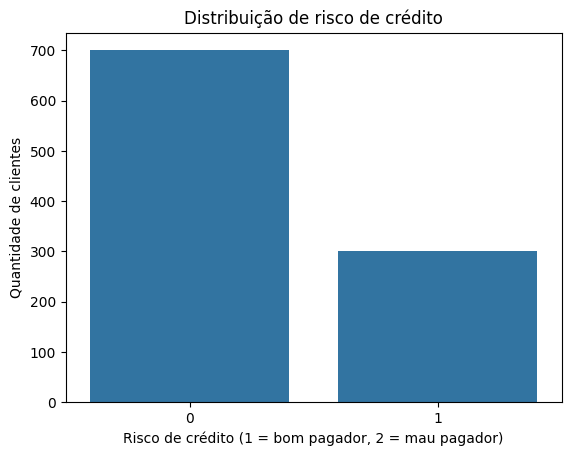

In [57]:
sns.countplot(x="credit_risk", data=df)

plt.title("Distribuição de risco de crédito")
plt.xlabel("Risco de crédito (1 = bom pagador, 2 = mau pagador)")
plt.ylabel("Quantidade de clientes")

plt.show()

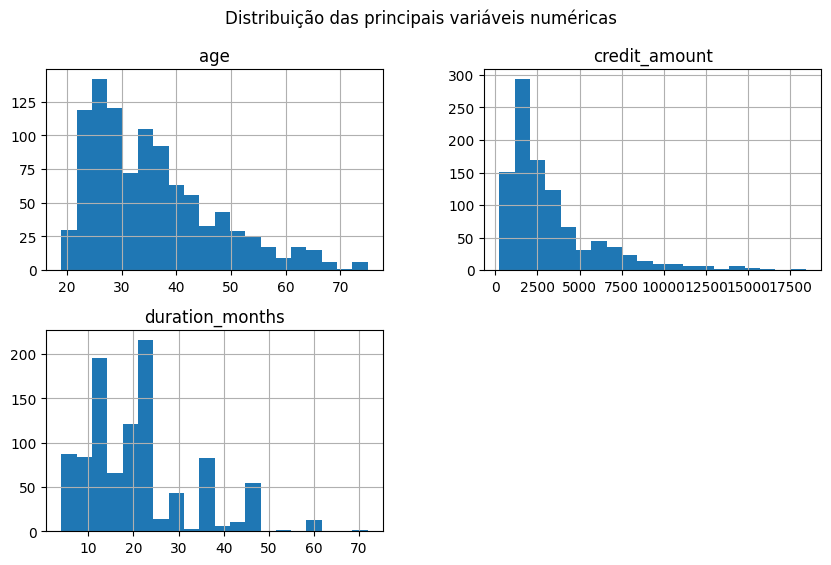

In [58]:
df[["age", "credit_amount", "duration_months"]].hist(bins=20, figsize=(10,6))

plt.suptitle("Distribuição das principais variáveis numéricas")

plt.show()

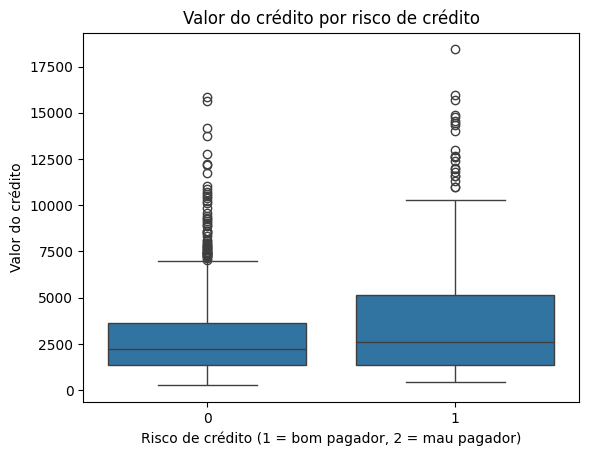

In [59]:
sns.boxplot(x="credit_risk", y="credit_amount", data=df)

plt.title("Valor do crédito por risco de crédito")
plt.xlabel("Risco de crédito (1 = bom pagador, 2 = mau pagador)")
plt.ylabel("Valor do crédito")

plt.show()

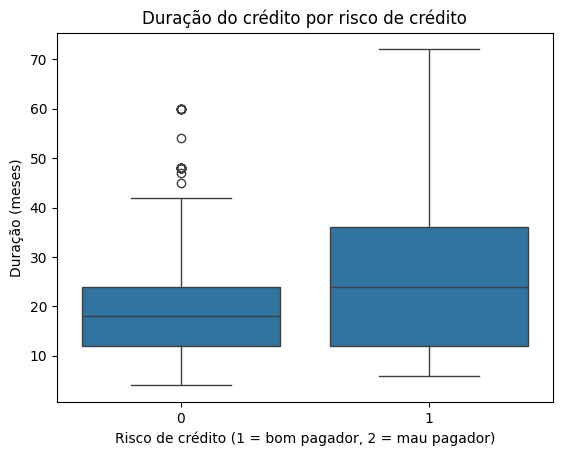

In [60]:
sns.boxplot(x="credit_risk", y="duration_months", data=df)

plt.title("Duração do crédito por risco de crédito")
plt.xlabel("Risco de crédito (1 = bom pagador, 2 = mau pagador)")
plt.ylabel("Duração (meses)")

plt.show()

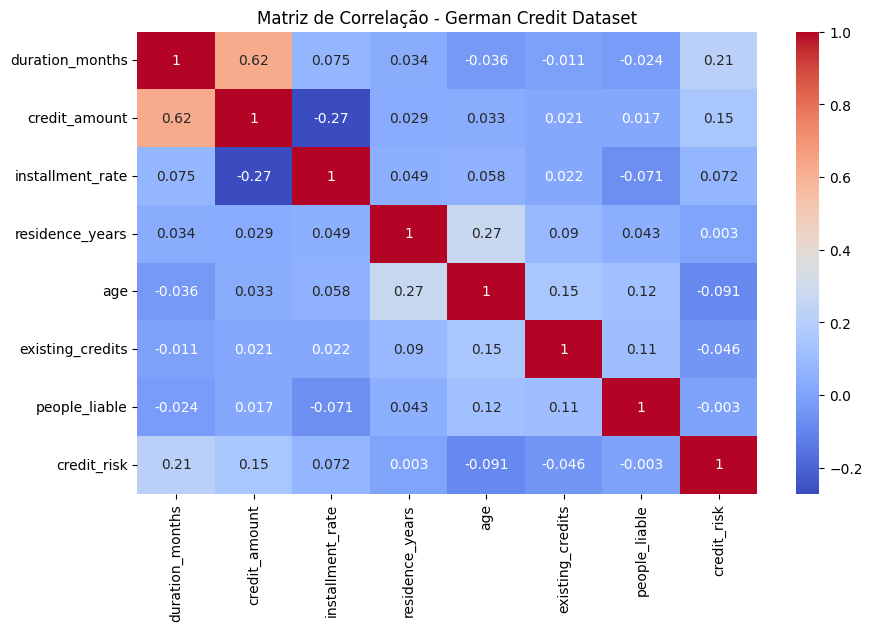

In [61]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Matriz de Correlação - German Credit Dataset")

plt.show()

In [62]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [63]:
df_encoded.shape

(1000, 49)

In [64]:
df_encoded.head()

,duration_months,credit_amount,installment_rate,residence_years,age,existing_credits,people_liable,credit_risk,checking_account_status_A12,checking_account_status_A13,checking_account_status_A14,credit_history_A31,credit_history_A32,credit_history_A33,credit_history_A34,purpose_A41,purpose_A410,purpose_A42,purpose_A43,purpose_A44,purpose_A45,purpose_A46,purpose_A48,purpose_A49,savings_account_A62,savings_account_A63,savings_account_A64,savings_account_A65,employment_years_A72,employment_years_A73,employment_years_A74,employment_years_A75,personal_status_sex_A92,personal_status_sex_A93,personal_status_sex_A94,other_debtors_A102,other_debtors_A103,property_A122,property_A123,property_A124,other_installment_plans_A142,other_installment_plans_A143,housing_A152,housing_A153,job_A172,job_A173,job_A174,telephone_A192,foreign_worker_A202
0,6,1169,4,4,67,2,1,0,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,1,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,0,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,0,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,True,False,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,True,False,True,False,True,False,False,False


In [65]:
X = df_encoded.drop("credit_risk", axis=1)
y = df_encoded["credit_risk"]

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [67]:
print(X_train.shape)
print(X_test.shape)

(800, 48)
(200, 48)


In [68]:
from sklearn.linear_model import LogisticRegression

# criando o modelo
model = LogisticRegression(max_iter=1000)

# treinando o modelo
model.fit(X_train, y_train)

c:\Users\walde\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [69]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 1, 1, 0, 0, 0, 0, 1, 0, 0])

In [70]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy do modelo:", accuracy)

Accuracy do modelo: 0.79


In [71]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       141
           1       0.68      0.54      0.60        59

    accuracy                           0.79       200
   macro avg       0.75      0.72      0.73       200
weighted avg       0.78      0.79      0.78       200



In [72]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[126  15]
 [ 27  32]]


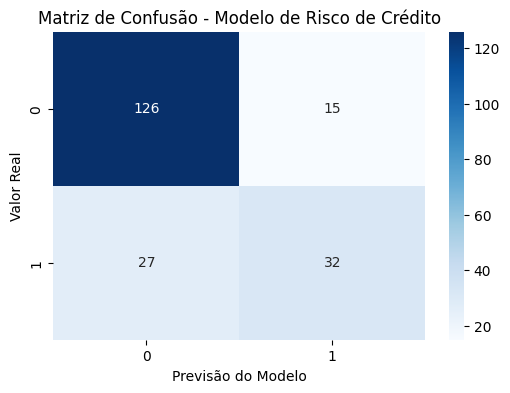

In [73]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Previsão do Modelo")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusão - Modelo de Risco de Crédito")

plt.show()

In [74]:
coefficients = pd.DataFrame({
    "Variavel": X.columns,
    "Coeficiente": model.coef_[0]
})

coefficients.head()

,Variavel,Coeficiente
0,duration_months,0.021777
1,credit_amount,0.000124
2,installment_rate,0.306150
3,residence_years,0.038651
4,age,-0.025620


In [75]:
coefficients_sorted = coefficients.sort_values(by="Coeficiente", ascending=False)

coefficients_sorted.head(10)

,Variavel,Coeficiente
20,purpose_A46,0.465109
10,credit_history_A31,0.431960
38,property_A124,0.425847
5,existing_credits,0.340822
36,property_A122,0.337327
2,installment_rate,0.306150
6,people_liable,0.237877
37,property_A123,0.223963
45,job_A174,0.182902
44,job_A173,0.148997


In [76]:
coefficients_sorted.tail(10)

,Variavel,Coeficiente
26,savings_account_A65,-0.639338
47,foreign_worker_A202,-0.664860
16,purpose_A42,-0.688161
17,purpose_A43,-0.693701
35,other_debtors_A103,-0.700146
25,savings_account_A64,-0.772397
8,checking_account_status_A13,-0.899776
13,credit_history_A34,-0.939229
14,purpose_A41,-1.326145
9,checking_account_status_A14,-1.478055


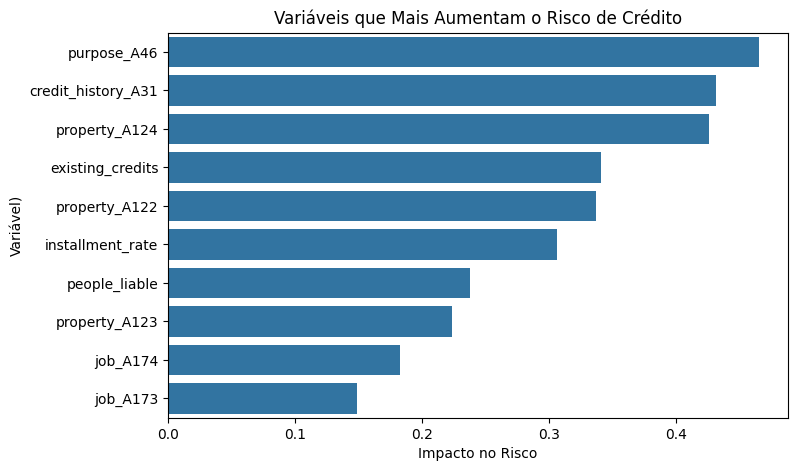

In [77]:
top_features = coefficients_sorted.head(10)

plt.figure(figsize=(8,5))
sns.barplot(x="Coeficiente", y="Variavel", data=top_features)

plt.title("Variáveis que Mais Aumentam o Risco de Crédito")
plt.xlabel("Impacto no Risco")
plt.ylabel("Variável)")

plt.show()

In [78]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [79]:
rf_pred = rf_model.predict(X_test)

rf_pred[:10]

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0])

In [80]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Accuracy Random Forest:", rf_accuracy)

Accuracy Random Forest: 0.74


In [81]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.76      0.91      0.83       141
           1       0.61      0.32      0.42        59

    accuracy                           0.74       200
   macro avg       0.69      0.62      0.63       200
weighted avg       0.72      0.74      0.71       200



In [82]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[129  12]
 [ 40  19]]


In [83]:
model_comparison = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy],
    "Recall Inadimplente": [0.54, 0.32]
})

model_comparison

,Modelo,Accuracy,Recall Inadimplente
0,Logistic Regression,0.79,0.54
1,Random Forest,0.74,0.32


In [84]:
importances = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": rf_model.feature_importances_
})

importances_sorted = importances.sort_values(by="Importancia", ascending=False)

importances_sorted.head(10)

,Variavel,Importancia
1,credit_amount,0.118543
4,age,0.099311
0,duration_months,0.085493
9,checking_account_status_A14,0.062062
2,installment_rate,0.042415
3,residence_years,0.038508
13,credit_history_A34,0.023455
5,existing_credits,0.022600
40,other_installment_plans_A143,0.021068
17,purpose_A43,0.020657


<function matplotlib.pyplot.show(close=None, block=None)>

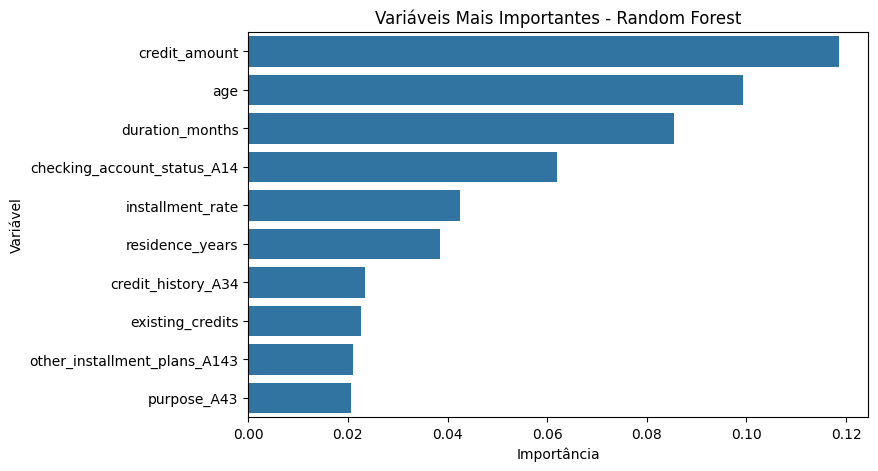

In [85]:
top_rf_features = importances_sorted.head(10)

plt.figure(figsize=(8,5))
sns.barplot(x="Importancia", y="Variavel", data=top_rf_features)

plt.title("Variáveis Mais Importantes - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.show

In [86]:
df.to_csv("german_credit_tratado.csv", index=False)

In [ ]:
df["previsao_modelo"] = model.predict(X)

df.to_csv("german_credit_com_previsoes.csv", index=False)